Multi-Task DNN - 3-Class Classification + Regression

Novel contribution: dual-output architecture with 3-class classification
head (peak return magnitude) trained jointly with a regression head.
- Classification: <2% (Class 0), 2-4% (Class 1), ≥4% (Class 2)
- Regression: peak return magnitude
- Flat encoder over all features

**How this notebook is organized:**
0. Setup - mount Drive, imports, device/seed config
1. Data Loading - join tech/fundamentals/sentiment/sector into one table
2. Feature List - flatten everything into a single input vector
3. Fold Construction - quarterly walk-forward train/val/test splits
4. Architecture & Training Function - shared encoder + dual heads
5. Baseline Run - default hyperparameters, no tuning
6. Hyperparameter Search & Final Tuned Model - two-phase Optuna search
7. Visualizations - accuracy over time, confusion matrix, return spread
8. Model Diagnostics - precision/recall, calibration, loss decomposition
9. Save Results - pickle outputs for cross-pipeline comparison


## Setup

Mounts Google Drive so the notebook can read the modeling parquet files and, at the end, write the results pickle back to Drive. Everything below assumes Drive is mounted at `/content/drive`.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Imports, Device, and Reproducibility

Pulls in Polars (data loading/joins), PyTorch (the multi-task DNN), scikit-learn (imputation, scaling, metrics), and Optuna (hyperparameter search). `set_seed()` is called at the start of every training run so folds are reproducible. Picks GPU if available, otherwise falls back to CPU. The `plt.rcParams` block forces a white background / black text theme so plots render legibly regardless of notebook theme.


In [2]:

import polars as pl
import numpy as np
import os, pickle, re, random

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix,
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

!pip install optuna -q
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = 'white'
plt.rcParams['text.color']       = 'black'
plt.rcParams['axes.labelcolor']  = 'black'
plt.rcParams['xtick.color']      = 'black'
plt.rcParams['ytick.color']      = 'black'
plt.rcParams['axes.edgecolor']   = 'black'


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Using device: cpu


/Users/richardpears/github/Post-Earnings-Forecast/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Loading

Joins tech indicators + fundamentals + FinBERT transcript sentiment + news sentiment + sector one-hot into a single modeling table, keyed on `(symbol, earnings_date)`. Identical to the TabNet notebook's data loading, so both advanced models are evaluated on the same information.

In [11]:
def _get_base_path():
    if os.path.isdir("/content/drive/MyDrive"):
        return "/content/drive/MyDrive/Post-Earnings/model_staging"
    return "../../data/model_staging"


def build_modeling_table(base_path: str = _get_base_path()) -> pl.DataFrame:
    """
    Loads and joins tech, fundamental, FinBERT, and news sentiment tables,
    plus one-hot encoded sector flags, into a single modeling DataFrame.
    """
    # Technical features (base table)
    df_tech = pl.read_parquet(f"{base_path}/tech_modeling_table.parquet")
    print(f"Loaded tech table with shape: {df_tech.shape}")
    # Fundamental indicators
    df_fund = pl.read_parquet(f"{base_path}/modeling_fundamentals.parquet")
    df_fund = df_fund.select([
        "symbol",
        pl.col("reportedDate").alias("earnings_date"),
        "eps_growth_qoq", "revenue_growth_qoq",
        "gross_margin",     "gross_margin_qoq",
        "debt_to_equity",   "debt_to_equity_qoq",
        "fcf_margin",       "fcf_margin_qoq",
        "roe",              "roe_qoq",
        "surprisePercentage",
    ])

    # FinBERT sentiment
    df_finbert = pl.read_parquet(f"{base_path}/finbert_tx_agg_weighted.parquet")
    df_finbert_feat = df_finbert.select([
        "symbol",
        pl.col("reportedDate").alias("earnings_date"),
        "pos_prob", "neg_prob",
    ])

    # News sentiment (pre/post)
    df_nz = pl.read_parquet(f"{base_path}/nz_sentiment.parquet")
    df_nz = df_nz.select([
        "symbol",
        pl.col("reportedDate").alias("earnings_date"),
        "overall_sentiment_score_pre",  "ticker_sentiment_score_pre",
        "overall_sentiment_score_post", "ticker_sentiment_score_post",
    ])

    # Join everything on symbol + earnings_date
    df_model = (
        df_tech
        .join(df_fund,       on=["symbol", "earnings_date"], how="left")
        .join(df_finbert_feat, on=["symbol", "earnings_date"], how="left")
        .join(df_nz,          on=["symbol", "earnings_date"], how="left")
    )

    # Sector one-hot encoding (reuses df_finbert since it's already loaded)
    df_sector = df_finbert.select(["symbol", "sector"]).unique()
    df_sector = df_sector.with_columns(pl.col("sector").fill_null("Unknown"))
    sectors = sorted(df_sector["sector"].unique().to_list())
    df_sector = df_sector.with_columns([
        (pl.col("sector") == s).cast(pl.Int8).alias(f"sector_{s.replace(' ', '_')}")
        for s in sectors
    ]).drop("sector")

    df_model = df_model.join(df_sector, on="symbol", how="left")

    # Drop CAR columns (not used in this model)
    df_model = df_model.drop([
    col for col in df_model.columns if col.startswith("car")
    ])

    print(f"Tech table shape: {df_tech.shape}")
    print(f"Combined table shape: {df_model.shape}")
    print(f"Target class distribution:\n{df_model['target_class'].value_counts().sort('target_class')}")

    return df_model

df_model = build_modeling_table()

Loaded tech table with shape: (24048, 243)
Tech table shape: (24048, 243)
Combined table shape: (24048, 270)
Target class distribution:
shape: (3, 2)
┌──────────────┬───────┐
│ target_class ┆ count │
│ ---          ┆ ---   │
│ i64          ┆ u32   │
╞══════════════╪═══════╡
│ 0            ┆ 7955  │
│ 1            ┆ 6428  │
│ 2            ┆ 9665  │
└──────────────┴───────┘


## 2. Feature List (Flat, Single Encoder)

All 257 features are concatenated into one flat vector - no per-modality encoders. The tech/VIX sequence columns are kept grouped and ordered by timestep purely so a future sequence-pooling ablation could slice them out without rebuilding folds; the model itself treats the whole vector as flat input regardless of this ordering.

In [16]:

exc = [
 'target_return_close_t10',
 'target_class_close_t10',
 'target_return_avg_high',
 'target_class_avg_high',
 'car_3day',
 'car_t2_t10',
 'max_high',
 'min_high',
 'max_day',
 'min_day']
EXCLUDE_COLS = [
    "symbol", "earnings_date", "entry_price", "target_return",
    "target_class", "max_high", "min_high", "max_day", "min_day", "year", "quarter",
] +exc
feature_cols = [c for c in df_model.columns if c not in EXCLUDE_COLS]

TECH_BASES = [
    "rsi", "macd", "macd_hist", "roc",
    "ema50_pct", "ema200_pct", "ema50_200_pct", "adx",
    "atr", "bb_width", "bb_pct_b", "sigma",
    "obv_zscore", "vwap_pct",
    "open_pct", "high_pct", "low_pct", "volume_rel",
]
VIX_BASES = ["vix_close"]
SEQ_BASES = TECH_BASES + VIX_BASES  # 19 indicators × 12 timesteps

def group_sequence_columns(all_cols, bases):
    groups = {}
    remaining = list(all_cols)
    for base in sorted(bases, key=len, reverse=True):
        matched = [c for c in remaining if c == base or c.startswith(base + "_")]
        def step_key(col, base=base):
            m = re.search(r"(-?\d+)", col[len(base):])
            return int(m.group(1)) if m else 0
        groups[base] = sorted(matched, key=step_key)
        remaining = [c for c in remaining if c not in matched]
    return {base: groups[base] for base in bases}

seq_groups = group_sequence_columns(feature_cols, SEQ_BASES)
timestep_counts = {len(c) for c in seq_groups.values()}
assert len(timestep_counts) == 1, f"Inconsistent timestep counts: {timestep_counts}"
n_timesteps = timestep_counts.pop()
seq_cols_ordered = [c for base in SEQ_BASES for c in seq_groups[base]]

other_cols = [c for c in feature_cols if c not in seq_cols_ordered]

flat_feature_cols = seq_cols_ordered + other_cols

assert len(flat_feature_cols) == len(feature_cols), (
    f"Feature count mismatch: flat={len(flat_feature_cols)}, original={len(feature_cols)}"
)
print(f"Sequence block: {len(seq_cols_ordered)} cols ({len(SEQ_BASES)} indicators × {n_timesteps} steps)")
print(f"Other (fundamentals/sentiment/sector): {len(other_cols)} cols")
print(f"Total flat features: {len(flat_feature_cols)}")

Sequence block: 228 cols (19 indicators × 12 steps)
Other (fundamentals/sentiment/sector): 29 cols
Total flat features: 257


## 3. Fold Construction - Quarterly Expanding Window

Builds walk-forward folds so the model is never evaluated on data it could have seen during training. For each fold:
- **Train** = everything before the validation quarter
- **Val** = the single quarter immediately before the test quarter (used only for early stopping)
- **Test** = the held-out quarter

The window expands forward through time - fold *N+1*'s training set is a superset of fold *N*'s. Imputation and scaling (`prep_block`) are fit on the training split only and applied unchanged to val/test, so no information about the future leaks into preprocessing.


In [17]:

def prep_block(train_df, val_df, test_df, cols):
    """Fit imputer + scaler on train ONLY. Val and test are transform-only."""
    Xtr = train_df.select(cols).to_numpy()
    Xva = val_df.select(cols).to_numpy()
    Xte = test_df.select(cols).to_numpy()

    Xtr = np.where(np.isinf(Xtr), np.nan, Xtr)
    Xva = np.where(np.isinf(Xva), np.nan, Xva)
    Xte = np.where(np.isinf(Xte), np.nan, Xte)

    imputer = SimpleImputer(strategy="median").fit(Xtr)
    Xtr = imputer.transform(Xtr)
    Xva = imputer.transform(Xva)
    Xte = imputer.transform(Xte)

    scaler = StandardScaler().fit(Xtr)
    return scaler.transform(Xtr), scaler.transform(Xva), scaler.transform(Xte)


INITIAL_TRAIN_YEARS = 7

df_model = df_model.with_columns([
    pl.col("earnings_date").dt.year().alias("year"),
    pl.col("earnings_date").dt.quarter().alias("quarter"),
])

df_model = df_model.filter(pl.col("year") <= 2025)

min_date = df_model["earnings_date"].min()
max_date = df_model["earnings_date"].max()
print(f"Dataset spans: {min_date} to {max_date}")
print(f"Total rows: {len(df_model)}\n")

unique_quarters = df_model.select(["year", "quarter"]).unique().sort(["year", "quarter"])
quarters_list = unique_quarters.to_dicts()

print("=" * 100)
print("EXPANDING WINDOW FOLD CONSTRUCTION (val = quarter before test)")
print("=" * 100)

earliest_year = quarters_list[0]["year"]
initial_train_end_year = earliest_year + INITIAL_TRAIN_YEARS - 1  # 2019
first_test_idx = next(i for i, q in enumerate(quarters_list) if q["year"] > initial_train_end_year)

print(f"Initial training period: {earliest_year}–{initial_train_end_year}")
print(f"Testing begins at: {quarters_list[first_test_idx]}")
print("=" * 100 + "\n")

folds_data = []
fold_num = 1

for test_quarter_idx in range(first_test_idx, len(quarters_list)):
    test_q = quarters_list[test_quarter_idx]
    val_q  = quarters_list[test_quarter_idx - 1]
    test_label = f"{test_q['year']}_Q{test_q['quarter']}"

    test_data = df_model.filter(
        (pl.col("year") == test_q["year"]) & (pl.col("quarter") == test_q["quarter"])
    )

    val_data = df_model.filter(
        (pl.col("year") == val_q["year"]) & (pl.col("quarter") == val_q["quarter"])
    )

    train_data = df_model.filter(
        (pl.col("year") < val_q["year"]) |
        ((pl.col("year") == val_q["year"]) & (pl.col("quarter") < val_q["quarter"]))
    )

    if len(train_data) == 0 or len(val_data) == 0 or len(test_data) == 0:
        continue

    X_tr, X_va, X_te = prep_block(train_data, val_data, test_data, flat_feature_cols)

    folds_data.append({
        "fold_num":     fold_num,
        "test_quarter": test_label,
        "X_train":      X_tr,
        "X_val":        X_va,
        "X_test":       X_te,
        "y_train_cls":  train_data["target_class"].to_numpy(),
        "y_val_cls":    val_data["target_class"].to_numpy(),
        "y_test_cls":   test_data["target_class"].to_numpy(),
        "y_train_ret":  train_data["target_return"].to_numpy(),
        "y_val_ret":    val_data["target_return"].to_numpy(),
        "y_test_ret":   test_data["target_return"].to_numpy(),
        "test_symbols":       test_data["symbol"].to_list(),
        "test_dates":         test_data["earnings_date"].to_list(),
        "test_entry_prices":  test_data["entry_price"].to_list(),
    })

    print(f"Fold {fold_num:2d} [{test_label}]:  "
          f"train={X_tr.shape[0]:6,}  "
          f"val={X_va.shape[0]:4,} ({val_q['year']}_Q{val_q['quarter']})  "
          f"test={X_te.shape[0]:4,}")

    fold_num += 1

n_features = len(flat_feature_cols)
print("=" * 100)
print(f"Total folds: {len(folds_data)}")
print(f"n_features: {n_features}")
print("=" * 100)

Dataset spans: 2014-01-07 to 2025-12-19
Total rows: 23106

EXPANDING WINDOW FOLD CONSTRUCTION (val = quarter before test)
Initial training period: 2014–2020
Testing begins at: {'year': 2021, 'quarter': 1}

Fold  1 [2021_Q1]:  train=12,683  val= 486 (2020_Q4)  test= 492
Fold  2 [2021_Q2]:  train=13,169  val= 492 (2021_Q1)  test= 493
Fold  3 [2021_Q3]:  train=13,661  val= 493 (2021_Q2)  test= 493
Fold  4 [2021_Q4]:  train=14,154  val= 493 (2021_Q3)  test= 492
Fold  5 [2022_Q1]:  train=14,647  val= 492 (2021_Q4)  test= 494
Fold  6 [2022_Q2]:  train=15,139  val= 494 (2022_Q1)  test= 495
Fold  7 [2022_Q3]:  train=15,633  val= 495 (2022_Q2)  test= 493
Fold  8 [2022_Q4]:  train=16,128  val= 493 (2022_Q3)  test= 493
Fold  9 [2023_Q1]:  train=16,621  val= 493 (2022_Q4)  test= 492
Fold 10 [2023_Q2]:  train=17,114  val= 492 (2023_Q1)  test= 498
Fold 11 [2023_Q3]:  train=17,606  val= 498 (2023_Q2)  test= 496
Fold 12 [2023_Q4]:  train=18,104  val= 496 (2023_Q3)  test= 498
Fold 13 [2024_Q1]:  train=

## 4. Multi-Task DNN - Architecture & Training Function

**Shared encoder:** [256, 128, 64] with BatchNorm + ReLU + Dropout(0.3) at each layer.
- **Classification head:** Linear(64→32) → ReLU → Linear(32→3)
- **Regression head:** Linear(64→32) → ReLU → Linear(32→1)

**Joint loss:** alpha × CrossEntropy + (1-alpha) × MSE.
Regression target is z-scored using training-set statistics only, unscaled at prediction.
Fixed epochs, no early stopping, no validation (professor's requirement).
Regularization: dropout + weight_decay + BatchNorm + fixed epoch count.

In [18]:
"""## 4. Multi-Task DNN - Architecture & Training Function

Shared encoder: [256, 128, 64] with BatchNorm + ReLU + Dropout.
- Classification head: Linear(64→32) → ReLU → Linear(32→3)
- Regression head: Linear(64→32) → ReLU → Linear(32→1)

Joint loss: alpha × CrossEntropy + (1-alpha) × MSE.
Regression target z-scored using training-set statistics only.
Early stopping on validation quarter (quarter before test),
with a minimum epoch floor to prevent premature stopping.
Regularization: dropout + weight_decay + BatchNorm + cosine LR schedule.
"""

def build_dnn(n_features, hidden=(256, 128, 64), head_hidden=32, n_classes=3, dropout=0.3):
    layers = []
    in_dim = n_features
    for h in hidden:
        layers += [nn.Linear(in_dim, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
        in_dim = h
    encoder = nn.Sequential(*layers)
    clf_head = nn.Sequential(nn.Linear(in_dim, head_hidden), nn.ReLU(), nn.Linear(head_hidden, n_classes))
    reg_head = nn.Sequential(nn.Linear(in_dim, head_hidden), nn.ReLU(), nn.Linear(head_hidden, 1))
    return nn.ModuleDict({"encoder": encoder, "clf_head": clf_head, "reg_head": reg_head})


def dnn_forward(modules, x):
    h = modules["encoder"](x)
    return modules["clf_head"](h), modules["reg_head"](h).squeeze(-1)


def train_dnn(f, n_features, hidden=(256, 128, 64), head_hidden=32, dropout=0.3,
              alpha=0.5, max_epochs=50, patience=15, min_epochs=15,
              batch_size=512, lr=1e-3, weight_decay=1e-4,
              seed=42, use_class_weights=True):
    """Train with early stopping on validation quarter.
    Model trains for at least min_epochs before early stopping can fire.
    Restores best weights when validation loss stops improving.
    """
    set_seed(seed)
    modules = build_dnn(n_features, hidden=hidden, head_hidden=head_hidden, dropout=dropout).to(device)

    y_mean, y_std = f["y_train_ret"].mean(), f["y_train_ret"].std()

    Xtr     = torch.FloatTensor(f["X_train"]).to(device)
    ytr_cls = torch.LongTensor(f["y_train_cls"]).to(device)
    ytr_ret = torch.FloatTensor((f["y_train_ret"] - y_mean) / y_std).to(device)

    Xva     = torch.FloatTensor(f["X_val"]).to(device)
    yva_cls = torch.LongTensor(f["y_val_cls"]).to(device)
    yva_ret = torch.FloatTensor((f["y_val_ret"] - y_mean) / y_std).to(device)

    Xte     = torch.FloatTensor(f["X_test"]).to(device)

    train_ds     = TensorDataset(Xtr, ytr_cls, ytr_ret)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)

    # Class weights: inverse-frequency
    if use_class_weights:
        classes, counts = np.unique(f["y_train_cls"], return_counts=True)
        assert len(classes) == 3, f"Training set missing a class - found {classes}"
        weights = 1.0 / counts
        weights = weights / weights.sum() * len(classes)
        class_weights = torch.FloatTensor(weights).to(device)
    else:
        class_weights = None

    clf_loss_fn = nn.CrossEntropyLoss(weight=class_weights)
    reg_loss_fn = nn.MSELoss()
    optimizer   = torch.optim.Adam(modules.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler   = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)

    # Training loop with early stopping
    history = {"total": [], "clf": [], "reg": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_loss = float("inf")
    best_epoch = 0
    best_state = None
    epochs_no_improve = 0

    for epoch in range(max_epochs):
        # ── Train ───────────────────────────────────────────────────
        modules.train()
        epoch_loss, epoch_clf, epoch_reg = 0.0, 0.0, 0.0
        correct, total = 0, 0

        for xb, yb_cls, yb_ret in train_loader:
            optimizer.zero_grad()
            clf_logits, reg_out = dnn_forward(modules, xb)
            l_clf = clf_loss_fn(clf_logits, yb_cls)
            l_reg = reg_loss_fn(reg_out, yb_ret)
            loss  = alpha * l_clf + (1 - alpha) * l_reg
            loss.backward()
            torch.nn.utils.clip_grad_norm_(modules.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item() * xb.size(0)
            epoch_clf  += l_clf.item() * xb.size(0)
            epoch_reg  += l_reg.item() * xb.size(0)
            correct    += (clf_logits.argmax(1) == yb_cls).sum().item()
            total      += xb.size(0)

        history["total"].append(epoch_loss / total)
        history["clf"].append(epoch_clf / total)
        history["reg"].append(epoch_reg / total)
        history["train_acc"].append(correct / total)
        scheduler.step()

        # ── Validate ────────────────────────────────────────────────
        modules.eval()
        with torch.no_grad():
            val_clf_logits, val_reg_out = dnn_forward(modules, Xva)
            val_l_clf = clf_loss_fn(val_clf_logits, yva_cls)
            val_l_reg = reg_loss_fn(val_reg_out, yva_ret)
            val_loss  = alpha * val_l_clf + (1 - alpha) * val_l_reg
            val_loss  = val_loss.item()
            val_acc = (val_clf_logits.argmax(1) == yva_cls).float().mean().item()

        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = {k: v.cpu().clone() for k, v in modules.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        # Early stopping only after min_epochs
        if epochs_no_improve >= patience and epoch >= min_epochs:
            break

    # Restore best weights
    modules.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    # ── Inference ───────────────────────────────────────────────────
    modules.eval()
    with torch.no_grad():
        test_clf_logits, test_reg_out = dnn_forward(modules, Xte)
        test_clf_probs = torch.softmax(test_clf_logits, dim=1).cpu().numpy()
        test_clf_preds = test_clf_probs.argmax(axis=1)
        test_reg_preds = (test_reg_out.cpu().numpy() * y_std) + y_mean

    return {
        "clf_preds":  test_clf_preds,
        "clf_probs":  test_clf_probs,
        "reg_preds":  test_reg_preds,
        "best_epoch": best_epoch,
        "epochs_ran": epoch + 1,
        "modules":    modules,
        "history":    history,
    }

## 5. Initial Run - Default Hyperparameters

Baseline run at default settings before any tuning. Reference point
for whether tuning actually helped — compare these numbers against
the tuned run in Section 6.

In [20]:
"""## 5. Initial Run — Default Hyperparameters

Baseline run at default settings on eval folds only. Same fold set
as the tuned run so the comparison is fair.
"""

N_TUNE_FOLDS = 4
eval_folds = folds_data[N_TUNE_FOLDS:]

default_clf = {"fold_acc": [], "preds": [], "probs": [], "true": [], "quarters": []}
default_reg = {"fold_mae": [], "fold_rmse": [], "preds": [], "true": []}
default_histories = []
default_per_fold_results = []

for fold in eval_folds:
    out = train_dnn(fold, n_features, seed=42 + fold["fold_num"])

    acc  = accuracy_score(fold["y_test_cls"], out["clf_preds"])
    default_clf["fold_acc"].append(acc)
    default_clf["preds"].extend(out["clf_preds"])
    default_clf["probs"].append(out["clf_probs"])
    default_clf["true"].extend(fold["y_test_cls"])
    default_clf["quarters"].append(fold["test_quarter"])

    mae  = mean_absolute_error(fold["y_test_ret"], out["reg_preds"])
    rmse = np.sqrt(mean_squared_error(fold["y_test_ret"], out["reg_preds"]))
    default_reg["fold_mae"].append(mae)
    default_reg["fold_rmse"].append(rmse)
    default_reg["preds"].extend(out["reg_preds"])
    default_reg["true"].extend(fold["y_test_ret"])
    default_histories.append(out["history"])

    default_per_fold_results.append({
        "quarter":        fold["test_quarter"],
        "fold_num":       fold["fold_num"],
        "symbols":        fold["test_symbols"].copy(),
        "earnings_dates": fold["test_dates"].copy(),
        "entry_prices":   fold["test_entry_prices"].copy(),
        "y_test_cls":     fold["y_test_cls"].copy(),
        "y_test_ret":     fold["y_test_ret"].copy(),
        "clf_preds":      out["clf_preds"].copy(),
        "clf_probs":      out["clf_probs"].copy(),
        "reg_preds":      out["reg_preds"].copy(),
    })

    pred_dist = np.bincount(out["clf_preds"].astype(int), minlength=3)
    train_acc = out["history"]["train_acc"][-1]

    print(f"Fold {fold['fold_num']:2d} [{fold['test_quarter']}]: "
          f"DA={acc:.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}  "
          f"train_acc={train_acc:.4f}  "
          f"best_epoch={out['best_epoch']}  "
          f"pred_dist={pred_dist}")

true_def  = np.array(default_clf["true"])
preds_def = np.array(default_clf["preds"])
probs_def = np.vstack(default_clf["probs"])

print(f"\nDNN (default) -- Avg DA:     {np.mean(default_clf['fold_acc']):.4f}")
print(f"DNN (default) -- Pooled F1:  {f1_score(true_def, preds_def, average='weighted'):.4f}")
print(f"DNN (default) -- Pooled AUC: {roc_auc_score(true_def, probs_def, multi_class='ovr', average='weighted'):.4f}")

true_r_def  = np.array(default_reg["true"])
preds_r_def = np.array(default_reg["preds"])
print(f"\nDNN (default) -- Avg MAE:  {np.mean(default_reg['fold_mae']):.4f}")
print(f"DNN (default) -- Avg RMSE: {np.mean(default_reg['fold_rmse']):.4f}")
print(f"DNN (default) -- Pooled R²: {r2_score(true_r_def, preds_r_def):.4f}")

print("\n" + classification_report(true_def, preds_def,
      target_names=["Low (<2%)", "Moderate (2-4%)", "Strong (≥4%)"]))
print("Confusion matrix:\n", confusion_matrix(true_def, preds_def))

# ── Build per-row DataFrame for analysis ──────────────────────────
import pandas as pd

default_rows = []
for pf in default_per_fold_results:
    n = len(pf["y_test_cls"])
    for i in range(n):
        default_rows.append({
            "quarter":                pf["quarter"],
            "fold_num":               pf["fold_num"],
            "symbol":                 str(pf["symbols"][i]),
            "earnings_date":          str(pf["earnings_dates"][i]),
            "entry_price":            float(pf["entry_prices"][i]),
            "target_class_actual":    int(pf["y_test_cls"][i]),
            "target_class_predicted": int(pf["clf_preds"][i]),
            "prob_class_0":           float(pf["clf_probs"][i][0]),
            "prob_class_1":           float(pf["clf_probs"][i][1]),
            "prob_class_2":           float(pf["clf_probs"][i][2]),
            "target_return_actual":   float(pf["y_test_ret"][i]),
            "target_return_predicted": float(pf["reg_preds"][i]),
        })

default_df = pd.DataFrame(default_rows)
print(f"\nDefault predictions DataFrame: {default_df.shape}")
print(default_df.groupby("quarter").size().describe())
print(f"\nFirst 5 rows:\n{default_df.head()}")

# Optional: export
import os
# save_dir = "/content/drive/MyDrive/models"
save_dir="*"
os.makedirs(save_dir, exist_ok=True)
default_df.to_csv(f"{save_dir}/multitask_dnn_default_predictions.csv", index=False)
print(f"Exported to {save_dir}/multitask_dnn_default_predictions.csv")

Fold  5 [2022_Q1]: DA=0.4737  MAE=0.0350  RMSE=0.0511  train_acc=0.5041  best_epoch=1  pred_dist=[  4  18 472]
Fold  6 [2022_Q2]: DA=0.3677  MAE=0.0437  RMSE=0.0516  train_acc=0.5074  best_epoch=0  pred_dist=[ 22   0 473]
Fold  7 [2022_Q3]: DA=0.5477  MAE=0.0272  RMSE=0.0346  train_acc=0.5029  best_epoch=0  pred_dist=[  0 152 341]
Fold  8 [2022_Q4]: DA=0.6937  MAE=0.0378  RMSE=0.0525  train_acc=0.4985  best_epoch=1  pred_dist=[  0   9 484]
Fold  9 [2023_Q1]: DA=0.4736  MAE=0.0255  RMSE=0.0333  train_acc=0.4977  best_epoch=0  pred_dist=[198  34 260]
Fold 10 [2023_Q2]: DA=0.4337  MAE=0.0239  RMSE=0.0382  train_acc=0.5096  best_epoch=0  pred_dist=[266   8 224]
Fold 11 [2023_Q3]: DA=0.4234  MAE=0.0207  RMSE=0.0306  train_acc=0.5077  best_epoch=4  pred_dist=[221 189  86]
Fold 12 [2023_Q4]: DA=0.4739  MAE=0.0321  RMSE=0.0426  train_acc=0.5043  best_epoch=3  pred_dist=[ 88 159 251]
Fold 13 [2024_Q1]: DA=0.3548  MAE=0.0266  RMSE=0.0430  train_acc=0.5014  best_epoch=0  pred_dist=[409   4  83]
F

## 6. Diagnostic Investigation — Is the model overfitting or underfitting?

The baseline run above shows modest, inconsistent accuracy across folds. Before touching features or the target, we first check whether the model is training properly at all: is it finding all the signal it can (and just needs more capacity/data), or is it overfitting (finding a shortcut early, then memorizing training noise)?

This section plots train vs. validation loss/accuracy across all 20 evaluation folds using the histories already captured during the baseline run — no retraining needed.

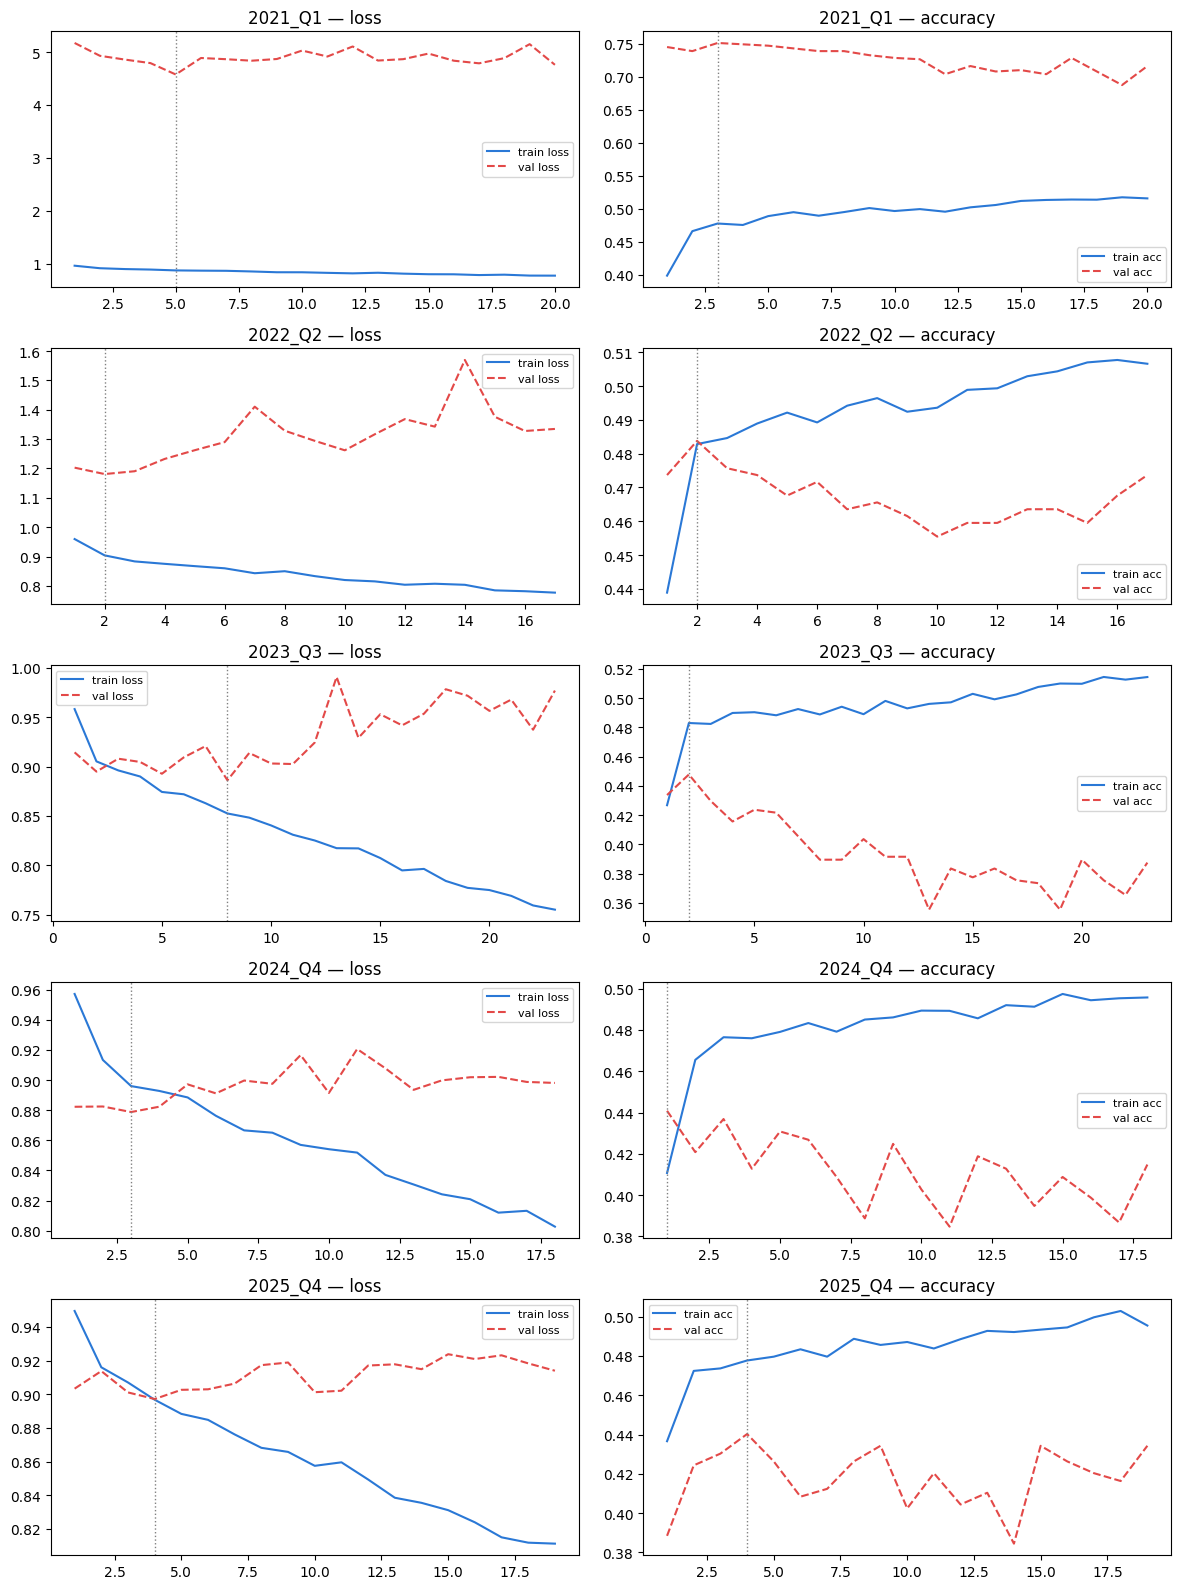

In [ ]:
import matplotlib.pyplot as plt

def plot_fold_curves(fold, hist, ax_loss, ax_acc):
    epochs = range(1, len(hist["total"]) + 1)
    ax_loss.plot(epochs, hist["total"], label="train loss", color="#2a78d6")
    ax_loss.plot(epochs, hist["val_loss"], label="val loss", color="#e34948", linestyle="--")
    ax_loss.axvline(np.argmin(hist["val_loss"]) + 1, color="gray", linestyle=":", linewidth=1)
    ax_loss.set_title(f"{fold['test_quarter']} — loss")
    ax_loss.legend(fontsize=8)

    ax_acc.plot(epochs, hist["train_acc"], label="train acc", color="#2a78d6")
    ax_acc.plot(epochs, hist["val_acc"], label="val acc", color="#e34948", linestyle="--")
    ax_acc.axvline(np.argmax(hist["val_acc"]) + 1, color="gray", linestyle=":", linewidth=1)
    ax_acc.set_title(f"{fold['test_quarter']} — accuracy")
    ax_acc.legend(fontsize=8)

# Plot a representative sample across the timeline — early, middle, late folds
sample_idx = [0, 5, 10, 15, 19]  # indices into eval_folds/default_histories
fig, axes = plt.subplots(len(sample_idx), 2, figsize=(12, 3.2 * len(sample_idx)))

for row, i in enumerate(sample_idx):
    plot_fold_curves(eval_folds[i], default_histories[i], axes[row, 0], axes[row, 1])

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/models/train_val_curves.png", dpi=120)
plt.show()

Plotting the full grid of all 20 folds (rather than a small sample) to confirm the pattern is universal, not fold-specific:

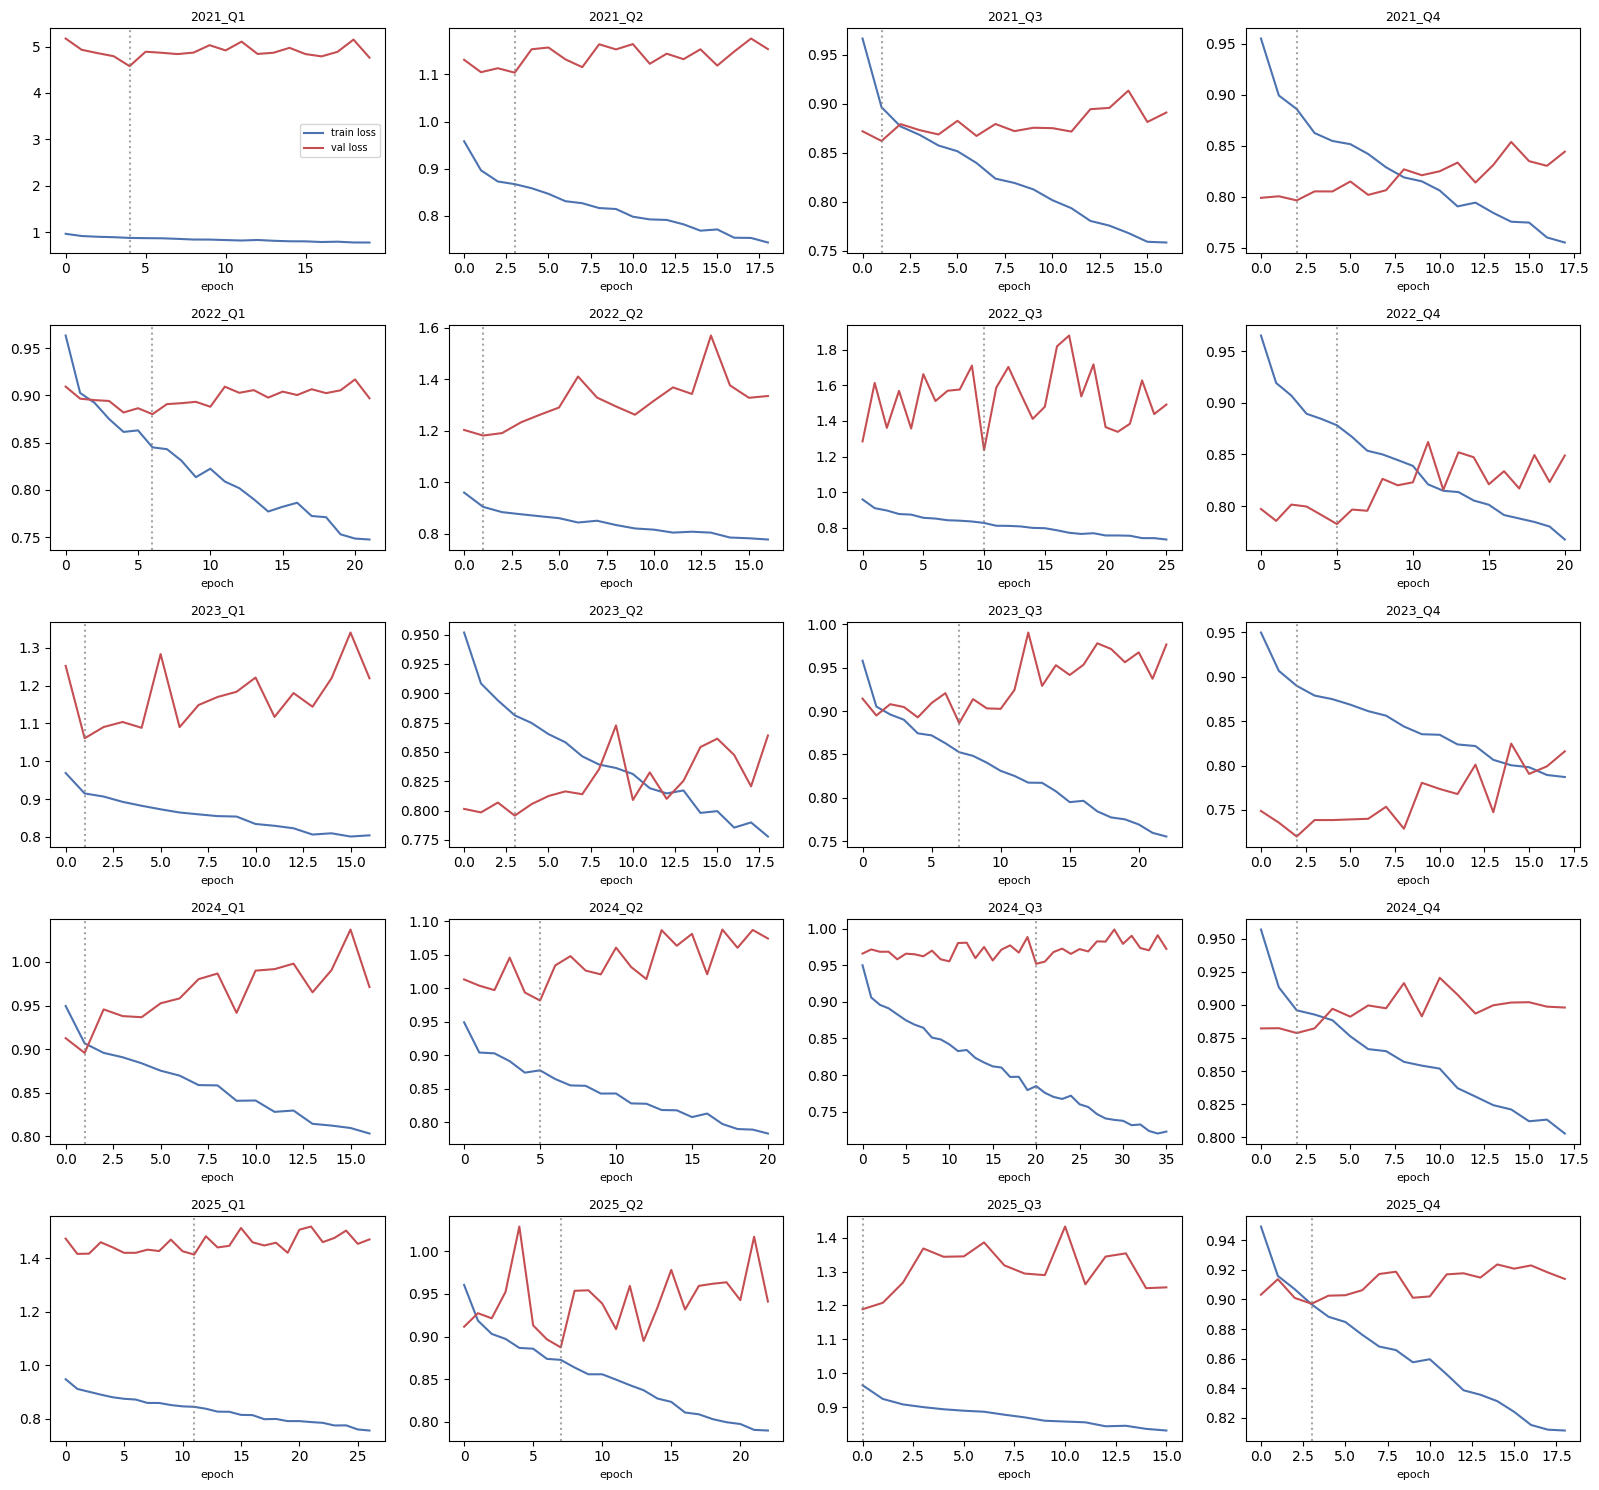

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

n = len(default_histories)
cols = 4
rows = -(-n // cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, 3 * rows))
axes = axes.flatten()

for i, h in enumerate(default_histories):
    ax = axes[i]
    ax.plot(h["total"],    color="#4C72B0", label="train loss")
    ax.plot(h["val_loss"], color="#C44E52", label="val loss")
    ax.axvline(int(np.argmin(h["val_loss"])), color="gray", ls=":", alpha=0.7)
    ax.set_title(default_clf["quarters"][i], fontsize=9)
    ax.set_xlabel("epoch", fontsize=8)
    if i == 0:
        ax.legend(fontsize=7)

for j in range(n, len(axes)):
    axes[j].axis("off")

plt.tight_layout(); plt.show()

**Reading the plots:** in every fold, training loss falls steadily for the whole run while validation loss flattens early or rises — the gap widens the longer training continues. Validation accuracy typically peaks in the first 2-8 epochs, then degrades. This is quantified below.

In [ ]:
summary = []
for fold, hist in zip(eval_folds, default_histories):
    peak_val_acc_epoch = int(np.argmax(hist["val_acc"]))
    best_val_loss_epoch = int(np.argmin(hist["val_loss"]))
    n_epochs = len(hist["val_acc"])

    train_val_gap_at_end = hist["train_acc"][-1] - hist["val_acc"][-1]
    val_loss_rose = hist["val_loss"][-1] > hist["val_loss"][best_val_loss_epoch]
    acc_selection_mismatch = peak_val_acc_epoch != best_val_loss_epoch

    summary.append({
        "quarter": fold["test_quarter"],
        "n_epochs": n_epochs,
        "best_val_loss_epoch": best_val_loss_epoch,
        "peak_val_acc_epoch": peak_val_acc_epoch,
        "selection_mismatch": acc_selection_mismatch,
        "val_loss_rose_after_best": val_loss_rose,
        "peak_val_acc": round(max(hist["val_acc"]), 3),
        "val_acc_at_selected_epoch": round(hist["val_acc"][best_val_loss_epoch], 3),
    })

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

print(f"\nFolds where val loss rose after its best point: {summary_df['val_loss_rose_after_best'].sum()} / 20")
print(f"Folds where loss-based stopping picked a different epoch than peak val_acc: {summary_df['selection_mismatch'].sum()} / 20")
print(f"Average gap between peak val_acc and val_acc-at-selected-epoch: {(summary_df['peak_val_acc'] - summary_df['val_acc_at_selected_epoch']).mean():.4f}")

quarter  n_epochs  best_val_loss_epoch  peak_val_acc_epoch  selection_mismatch  val_loss_rose_after_best  peak_val_acc  val_acc_at_selected_epoch
2021_Q1        20                    4                   2                True                      True         0.751                      0.747
2021_Q2        19                    3                   0                True                      True         0.589                      0.583
2021_Q3        17                    1                  11                True                      True         0.410                      0.379
2021_Q4        18                    2                   2               False                      True         0.446                      0.446
2022_Q1        22                    6                   4                True                      True         0.467                      0.443
2022_Q2        17                    1                   1               False                      True         0.484      

**Conclusion:** the model is not underfitting — it keeps improving its fit to training data indefinitely. It overfits: it finds a coarse, workable answer almost immediately, then spends the rest of training fitting noise that hurts generalization. Early stopping is doing necessary work here, though it isn't perfectly tuned (see `selection_mismatch` above — the epoch picked by lowest validation *loss* isn't always the epoch with the best validation *accuracy*).

## 7. Target Variable Investigation

This is the core investigation. It started from one observation — NVDA's predicted class never changed across 20 straight test quarters — and expanded into a population-wide check of how the prediction target itself is built, and whether that construction is driving the model's behavior more than the model or features are.

### 7.1 Seed observation: NVDA always predicted class 2

A quick look at one symbol's predictions across all 20 test quarters:

In [ ]:
default_df[default_df['symbol'] == 'NVDA'].sort_values(by='earnings_date', ascending=False)

,quarter,fold_num,symbol,earnings_date,entry_price,target_class_actual,target_class_predicted,prob_class_0,prob_class_1,prob_class_2,target_return_actual,target_return_predicted
9678,2025_Q4,24,NVDA,2025-11-19,180.620163,1,2,0.241410,0.245934,0.512656,0.027790,0.069709
9175,2025_Q3,23,NVDA,2025-08-27,180.140060,0,2,0.281597,0.334159,0.384244,0.000667,0.049087
8673,2025_Q2,22,NVDA,2025-05-28,139.157211,2,1,0.324588,0.353679,0.321733,0.041742,0.039234
8172,2025_Q1,21,NVDA,2025-02-26,120.110649,2,2,0.168724,0.223248,0.608028,0.041115,0.073131
7669,2024_Q4,20,NVDA,2024-11-20,146.611862,0,2,0.210472,0.280215,0.509313,0.003341,0.061450
7167,2024_Q3,19,NVDA,2024-08-28,117.533325,1,2,0.231986,0.281621,0.486393,0.035377,0.054185
6667,2024_Q2,18,NVDA,2024-05-22,103.740456,2,2,0.193757,0.221526,0.584717,0.209906,0.079924
6170,2024_Q1,17,NVDA,2024-02-21,78.490028,2,2,0.226091,0.283947,0.489962,0.142481,0.059312
5673,2023_Q4,16,NVDA,2023-11-21,48.681961,0,1,0.318172,0.358058,0.323770,0.004208,0.036208
5177,2023_Q3,15,NVDA,2023-08-23,47.126163,2,2,0.201251,0.220505,0.578244,0.058605,0.073890


In [ ]:
default_df[default_df['symbol'] == 'COST'].sort_values(by='earnings_date', ascending=False)

,quarter,fold_num,symbol,earnings_date,entry_price,target_class_actual,target_class_predicted,prob_class_0,prob_class_1,prob_class_2,target_return_actual,target_return_predicted
9811,2025_Q4,24,COST,2025-12-11,881.983459,0,1,0.381142,0.385904,0.232954,0.003415,0.031028
9308,2025_Q3,23,COST,2025-09-25,912.084717,1,1,0.403105,0.413784,0.183111,0.030373,0.026892
8806,2025_Q2,22,COST,2025-06-05,1009.258728,0,0,0.433087,0.392747,0.174166,-0.001567,0.027491
8305,2025_Q1,21,COST,2025-03-06,957.664368,0,1,0.360063,0.397494,0.242443,-0.004822,0.031448
7802,2024_Q4,20,COST,2024-12-12,981.447327,0,0,0.497640,0.374745,0.127615,0.019104,0.021802
7300,2024_Q3,19,COST,2024-09-26,877.380127,1,0,0.451998,0.382919,0.165082,0.027529,0.024740
6799,2024_Q2,18,COST,2024-06-06,836.521729,1,0,0.465248,0.373241,0.161511,0.033563,0.024920
6301,2024_Q1,17,COST,2024-03-07,716.637268,1,0,0.494128,0.368481,0.137391,0.036868,0.023991
5804,2023_Q4,16,COST,2023-12-14,635.315491,1,0,0.478699,0.401005,0.120296,0.037892,0.019859
5307,2023_Q3,15,COST,2023-09-26,542.429688,1,0,0.462418,0.392022,0.145560,0.022465,0.025250


In [ ]:
default_df[['target_class_actual', 'target_class_predicted']].value_counts(sort=False).sort_index()

target_class_actual  target_class_predicted
0                    0                          792
                     1                          792
                     2                         1287
1                    0                          666
                     1                          742
                     2                         1179
2                    0                          653
                     1                          892
                     2                         2934
Name: count, dtype: int64

## Strategies -

### 1 - Buy at close t+1 , when pred is 1,2 , exit - hits target if max is >2%  or exit at t10 close 
### loss/gain , sharpe ratio, equity curve , per quarter balance | | 

###  Equity curve cals are on the earnings dates for each quarter 
### equity curve - percentage diff0-- for each day 

Jan - 5th 2021 / 3 buys positions / 1000 CAD worth each total 3k / 

- In total Gain/Loss = 3.5K  / gain = 500/3000 on Jan 5th  - 2%  

Jan -7th / 4 positions / 1000 CAD worth each total 4k /
- In total Gain/Loss = 2.5% gain equity curve - starts with 0 hits 4.5%  cumsum 


#### downstream look at stoploss /




In [ ]:
w = 742 + 1179 + 892 + 2934
l = 792 + 1287 
print(w/(l+w))

# - calculate the  min of low from ohclv  t2 - t10 

# 

### 7.2 Is this a one-off, or does it happen for other symbols too?

Checking broadly: how many symbols get the identical predicted class in every single test quarter?

In [ ]:
# Per-symbol prediction diversity: how many distinct classes did each symbol get?
symbol_diversity = (
    default_df.groupby("symbol")["target_class_predicted"]
    .nunique()
    .sort_values()
)

n_locked = (symbol_diversity == 1).sum()
n_total  = len(symbol_diversity)
print(f"{n_locked} / {n_total} symbols were predicted the SAME class every single quarter")
print("\nSymbols locked onto one class:")
print(symbol_diversity[symbol_diversity == 1])

# For locked symbols, which class did they lock onto, and how often is it wrong?
locked_symbols = symbol_diversity[symbol_diversity == 1].index
for sym in locked_symbols:
    sub = default_df[default_df["symbol"] == sym]
    locked_class = sub["target_class_predicted"].iloc[0]
    acc = (sub["target_class_actual"] == locked_class).mean()
    print(f"{sym}: always predicted class {locked_class}, "
          f"actual matches {acc:.0%} of the time (n={len(sub)})")

17 / 502 symbols were predicted the SAME class every single quarter

Symbols locked onto one class:
symbol
BLDR    1
APP     1
SNDK    1
TTD     1
MRNA    1
NCLH    1
RCL     1
PLTR    1
HOOD    1
MPWR    1
WBD     1
ALB     1
COHR    1
COIN    1
CVNA    1
DDOG    1
VRT     1
Name: target_class_predicted, dtype: int64
BLDR: always predicted class 2, actual matches 75% of the time (n=20)
APP: always predicted class 2, actual matches 83% of the time (n=18)
SNDK: always predicted class 2, actual matches 100% of the time (n=4)
TTD: always predicted class 2, actual matches 65% of the time (n=20)
MRNA: always predicted class 2, actual matches 30% of the time (n=20)
NCLH: always predicted class 2, actual matches 65% of the time (n=20)
RCL: always predicted class 2, actual matches 55% of the time (n=20)
PLTR: always predicted class 2, actual matches 85% of the time (n=20)
HOOD: always predicted class 2, actual matches 76% of the time (n=17)
MPWR: always predicted class 2, actual matches 70% of

pct_predicted_that_class: out of all the times the model made a prediction for this stock, what percentage of those predictions were the exact same class?

In [ ]:
symbol_stats = (
    default_df.groupby("symbol")
    .apply(lambda g: pd.Series({
        "n": len(g),
        "most_common_prediction": g["target_class_predicted"].mode()[0],
        "pct_predicted_that_class": (g["target_class_predicted"] == g["target_class_predicted"].mode()[0]).mean(),
        "acc": (g["target_class_actual"] == g["target_class_predicted"]).mean(),
    }), include_groups=False)
    .reset_index()
)

symbol_stats = symbol_stats[symbol_stats["n"] >= 10]

# Sort by how "stuck" the model is on one answer for that symbol
symbol_stats = symbol_stats.sort_values("pct_predicted_that_class", ascending=False)
print(symbol_stats.head(30).to_string(index=False))

print(f"\nCorrelation: how often model repeats one guess vs. accuracy = "
      f"{symbol_stats['pct_predicted_that_class'].corr(symbol_stats['acc']):.3f}")

symbol    n  most_common_prediction  pct_predicted_that_class      acc
   WBD 20.0                     2.0                      1.00 0.800000
   ALB 20.0                     2.0                      1.00 0.700000
   VRT 20.0                     2.0                      1.00 0.650000
  ALGN 20.0                     2.0                      1.00 0.700000
   AMD 20.0                     2.0                      1.00 0.700000
   APP 18.0                     2.0                      1.00 0.833333
  ANET 20.0                     2.0                      1.00 0.500000
  UBER 20.0                     2.0                      1.00 0.550000
   UAL 20.0                     2.0                      1.00 0.600000
  BLDR 20.0                     2.0                      1.00 0.750000
   RCL 20.0                     2.0                      1.00 0.550000
  CRWD 20.0                     2.0                      1.00 0.600000
  CVNA 20.0                     2.0                      1.00 0.700000
  COIN

In [ ]:
print(symbol_stats["pct_predicted_that_class"].describe())

# how many stocks fall into different repetition bands?
bins = [0, 0.5, 0.7, 0.9, 0.99, 1.01]
labels = ["<50%", "50-70%", "70-90%", "90-99%", "100%"]
symbol_stats["band"] = pd.cut(symbol_stats["pct_predicted_that_class"], bins=bins, labels=labels)
print(symbol_stats["band"].value_counts().sort_index())

count    497.000000
mean       0.615004
std        0.185716
min        0.350000
25%        0.450000
50%        0.550000
75%        0.750000
max        1.000000
Name: pct_predicted_that_class, dtype: float64
band
<50%      203
50-70%    150
70-90%     98
90-99%     19
100%       27
Name: count, dtype: int64


In [ ]:
print(f"Correlation across ALL 497 symbols: {symbol_stats['pct_predicted_that_class'].corr(symbol_stats['acc']):.3f}")

Correlation across ALL 497 symbols: 0.571
